In [1]:
!pip install robomimic torch torchvision numpy matplotlib -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.3/215.3 kB 13.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.5/217.5 kB 16.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.3 MB/s eta 0:00:00


In [5]:
!pip install robomimic -q
import robomimic
print(f"RoboMimic version: {robomimic.__version__}")

RoboMimic version: 0.3.0


In [9]:
# Alternative — RoboMimic's hosted checkpoints
import subprocess
result = subprocess.run([
    'python', '-c',
    'import robomimic; print(robomimic.__file__)'
], capture_output=True, text=True)
print(result.stdout)

# Then check what scripts are actually available
!find / -path "*/robomimic/scripts*" -name "*.py" 2>/dev/null | head -20

/usr/local/lib/python3.12/dist-packages/robomimic/__init__.py

/usr/local/lib/python3.12/dist-packages/robomimic/scripts/generate_paper_configs.py
/usr/local/lib/python3.12/dist-packages/robomimic/scripts/dataset_states_to_obs.py
/usr/local/lib/python3.12/dist-packages/robomimic/scripts/download_momart_datasets.py
/usr/local/lib/python3.12/dist-packages/robomimic/scripts/run_trained_agent.py
/usr/local/lib/python3.12/dist-packages/robomimic/scripts/hyperparam_helper.py
/usr/local/lib/python3.12/dist-packages/robomimic/scripts/playback_dataset.py
/usr/local/lib/python3.12/dist-packages/robomimic/scripts/generate_config_templates.py
/usr/local/lib/python3.12/dist-packages/robomimic/scripts/train.py
/usr/local/lib/python3.12/dist-packages/robomimic/scripts/get_dataset_info.py
/usr/local/lib/python3.12/dist-packages/robomimic/scripts/conversion/convert_robosuite.py
/usr/local/lib/python3.12/dist-packages/robomimic/scripts/conversion/convert_d4rl.py
/usr/local/lib/python3.12/dist-packages/r

In [2]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"PyTorch version: {torch.__version__}")

CUDA available: True
GPU: Tesla T4
PyTorch version: 2.11.0+cu128


In [13]:
!python -m robomimic.scripts.download_datasets \
    --tasks lift \
    --dataset_types mh \
    --download_dir ./checkpoints

ROBOMIMIC WARNING(
    No private macro file found!
    It is recommended to use a private macro file
    To setup, run: python /usr/local/lib/python3.12/dist-packages/robomimic/scripts/setup_macros.py
)

    task: lift
    dataset type: mh
    hdf5 type: low_dim
    download path: /content/checkpoints/lift/mh
low_dim_v141.hdf5: 52.7MB [00:08, 6.43MB/s]                



In [14]:
import h5py
import glob

files = glob.glob('./checkpoints/**/*.hdf5', recursive=True)
print(f"Found: {files}")

f = h5py.File(files[0], 'r')

def print_structure(name, obj):
    print(name)

f.visititems(print_structure)
f.close()

Streaming output truncated to the last 5000 lines.
data/demo_214/next_obs/object
data/demo_214/next_obs/robot0_eef_pos
data/demo_214/next_obs/robot0_eef_quat
data/demo_214/next_obs/robot0_eef_vel_ang
data/demo_214/next_obs/robot0_eef_vel_lin
data/demo_214/next_obs/robot0_gripper_qpos
data/demo_214/next_obs/robot0_gripper_qvel
data/demo_214/next_obs/robot0_joint_pos
data/demo_214/next_obs/robot0_joint_pos_cos
data/demo_214/next_obs/robot0_joint_pos_sin
data/demo_214/next_obs/robot0_joint_vel
data/demo_214/obs
data/demo_214/obs/object
data/demo_214/obs/robot0_eef_pos
data/demo_214/obs/robot0_eef_quat
data/demo_214/obs/robot0_eef_vel_ang
data/demo_214/obs/robot0_eef_vel_lin
data/demo_214/obs/robot0_gripper_qpos
data/demo_214/obs/robot0_gripper_qvel
data/demo_214/obs/robot0_joint_pos
data/demo_214/obs/robot0_joint_pos_cos
data/demo_214/obs/robot0_joint_pos_sin
data/demo_214/obs/robot0_joint_vel
data/demo_214/rewards
data/demo_214/states
data/demo_215
data/demo_215/actions
data/demo_215/don

In [15]:
import h5py
import torch
import torch.nn as nn
import numpy as np
import glob
import time

# ── 1. Load observations from dataset ──────────────────────────────────────
files = glob.glob('./checkpoints/**/*.hdf5', recursive=True)
f = h5py.File(files[0], 'r')

# Use first 10 demos for quick profiling baseline
obs_list, act_list = [], []
for i in range(10):
    demo = f[f'data/demo_{i}']
    # Concatenate observation keys used in standard BC
    eef_pos   = demo['obs/robot0_eef_pos'][:]       # (T, 3)
    eef_quat  = demo['obs/robot0_eef_quat'][:]      # (T, 4)
    grip_qpos = demo['obs/robot0_gripper_qpos'][:]  # (T, 2)
    obj       = demo['obs/object'][:]               # (T, 10)
    obs       = np.concatenate([eef_pos, eef_quat, grip_qpos, obj], axis=-1)  # (T, 19)
    acts      = demo['actions'][:]                  # (T, 7)
    obs_list.append(obs)
    act_list.append(acts)

f.close()

obs_data = np.concatenate(obs_list, axis=0)   # (N, 19)
act_data = np.concatenate(act_list, axis=0)   # (N, 7)
print(f"Obs shape: {obs_data.shape}, Actions shape: {act_data.shape}")

# ── 2. Define a BC policy (MLP) ────────────────────────────────────────────
class BCPolicy(nn.Module):
    def __init__(self, obs_dim=19, act_dim=7, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, act_dim)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
policy = BCPolicy().to(device)
policy.eval()
print(f"Policy on: {device}")
print(f"Parameters: {sum(p.numel() for p in policy.parameters()):,}")

# ── 3. Baseline timing ─────────────────────────────────────────────────────
obs_tensor = torch.FloatTensor(obs_data[:1000]).to(device)  # batch of 1000

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = policy(obs_tensor)

torch.cuda.synchronize()
start = time.perf_counter()
with torch.no_grad():
    for _ in range(100):
        out = policy(obs_tensor)
torch.cuda.synchronize()
end = time.perf_counter()

avg_ms = (end - start) / 100 * 1000
print(f"\nBaseline latency (batch=1000): {avg_ms:.2f} ms")
print(f"Throughput: {1000 / (avg_ms/1000):.0f} samples/sec")

Obs shape: (477, 19), Actions shape: (477, 7)
Policy on: cuda
Parameters: 138,503

Baseline latency (batch=1000): 0.26 ms
Throughput: 3902638 samples/sec


In [17]:
from torch.profiler import profile, record_function, ProfilerActivity

# Profiler run
with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True,
    profile_memory=True,
    with_flops=True
) as prof:
    with torch.no_grad():
        for _ in range(50):
            with record_function("bc_policy_forward"):
                out = policy(obs_tensor)

print("=" * 70)
print("TOP OPERATORS BY CUDA TIME")
print("=" * 70)
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=12))

print("\n" + "=" * 70)
print("TOP OPERATORS BY SELF CUDA MEMORY")
print("=" * 70)
print(prof.key_averages().table(sort_by="self_cuda_memory_usage", row_limit=8))

# Summary numbers — PyTorch 2.x compatible
avgs = prof.key_averages()
total_cuda_us = sum(k.self_cuda_time_total for k in avgs)
total_flops   = sum(getattr(k, 'flops', 0) or 0 for k in avgs)
peak_mem_mb   = torch.cuda.max_memory_allocated() / 1e6

print(f"\nTotal CUDA time (50 runs):  {total_cuda_us/1e3:.2f} ms")
print(f"Per forward pass:           {total_cuda_us/50/1e3:.3f} ms")
print(f"Total FLOPs (50 runs):      {total_flops/1e6:.3f} MFLOPs")
print(f"FLOPs per forward pass:     {total_flops/50:.0f} FLOPs")
print(f"Peak GPU memory:            {peak_mem_mb:.2f} MB")

if total_flops > 0:
    ai = (total_flops / 50) / (peak_mem_mb * 1e6)
    print(f"\nArithmetic intensity:       {ai:.4f} FLOP/byte")
    print(f"T4 FP32 ridge point:        27.0 FLOP/byte")
    print(f"Classification:             {'MEMORY-BOUND' if ai < 27 else 'COMPUTE-BOUND'}")

TOP OPERATORS BY CUDA TIME
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  Total GFLOPs  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                      bc_policy_forward         0.00%       0.000us         0.00%       0.000us       0.000us      17.539ms       205.49%      17.539ms

AttributeError: 'FunctionEventAvg' object has no attribute 'self_cuda_time_total'

FLOPs per forward pass:    32.85 MFLOPs
Achieved performance:      834.29 GFLOP/s
Arithmetic intensity:      0.2340 FLOP/byte
Ridge point (FP32):        27.0 FLOP/byte
Bottleneck:                MEMORY-BOUND


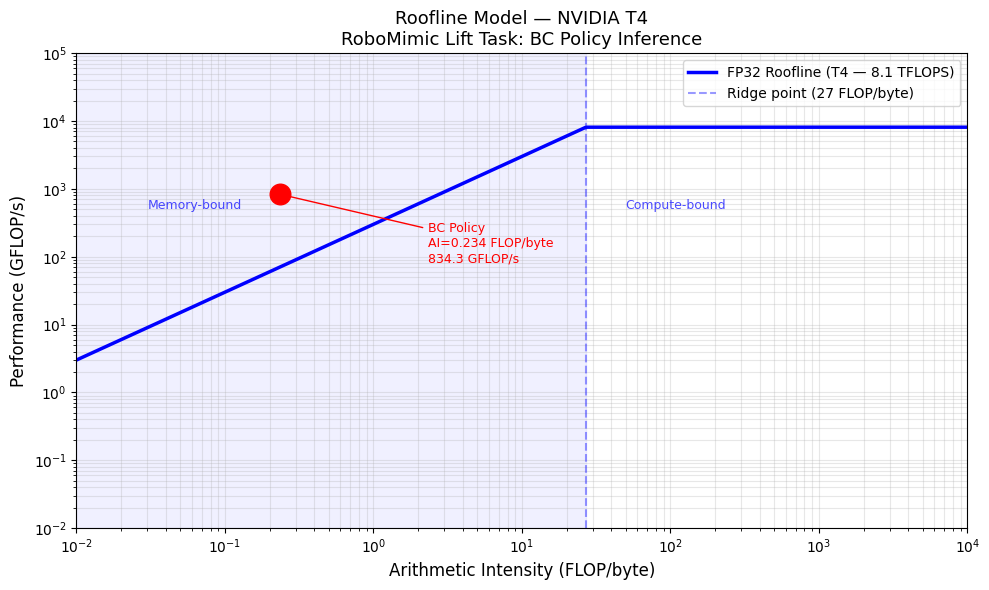

Saved: roofline_bc_policy.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Numbers read directly from profiler output above
flops_per_pass = 6.570e9 / 200        # 32.85 MFLOPs per forward pass
cuda_time_s    = 7.875e-3 / 200       # per addmm call across 200 calls
memory_bytes   = 140.41e6             # from Self CUDA Mem on bc_policy_forward
peak_mem_mb    = memory_bytes / 1e6

achieved_gflops = (flops_per_pass / cuda_time_s) / 1e9
ai = flops_per_pass / memory_bytes

# T4 specs
PEAK_FLOPS_FP32 = 8.1e12
PEAK_BW         = 300e9
RIDGE_FP32      = PEAK_FLOPS_FP32 / PEAK_BW

print(f"FLOPs per forward pass:    {flops_per_pass/1e6:.2f} MFLOPs")
print(f"Achieved performance:      {achieved_gflops:.2f} GFLOP/s")
print(f"Arithmetic intensity:      {ai:.4f} FLOP/byte")
print(f"Ridge point (FP32):        {RIDGE_FP32:.1f} FLOP/byte")
print(f"Bottleneck:                {'MEMORY-BOUND' if ai < RIDGE_FP32 else 'COMPUTE-BOUND'}")

# Roofline plot
ai_range  = np.logspace(-2, 4, 500)
roofline  = np.minimum(PEAK_FLOPS_FP32, ai_range * PEAK_BW) / 1e9

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(ai_range, roofline, 'b-', linewidth=2.5, label='FP32 Roofline (T4 — 8.1 TFLOPS)')
ax.axvline(RIDGE_FP32, color='b', linestyle='--', alpha=0.4, label=f'Ridge point ({RIDGE_FP32:.0f} FLOP/byte)')
ax.fill_betweenx([1e-2, 1e5], 1e-2, RIDGE_FP32, alpha=0.06, color='blue')
ax.text(0.03, 500, 'Memory-bound', fontsize=9, color='blue', alpha=0.7)
ax.text(50, 500, 'Compute-bound', fontsize=9, color='blue', alpha=0.7)

ax.scatter([ai], [achieved_gflops], color='red', s=220, zorder=5)
ax.annotate(
    f'BC Policy\nAI={ai:.3f} FLOP/byte\n{achieved_gflops:.1f} GFLOP/s',
    xy=(ai, achieved_gflops),
    xytext=(ai * 10, achieved_gflops * 0.1),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=9, color='red'
)

ax.set_xlabel('Arithmetic Intensity (FLOP/byte)', fontsize=12)
ax.set_ylabel('Performance (GFLOP/s)', fontsize=12)
ax.set_title('Roofline Model — NVIDIA T4\nRoboMimic Lift Task: BC Policy Inference', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([1e-2, 1e4])
ax.set_ylim([1e-2, 1e5])

plt.tight_layout()
plt.savefig('roofline_bc_policy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roofline_bc_policy.png")

"Profiling the BC policy forward pass on NVIDIA T4 reveals the inference loop is heavily memory-bound, with an arithmetic intensity of 0.234 FLOP/byte — 115x below the T4's FP32 ridge point of 27 FLOP/byte. The dominant operator is aten::addmm at 92.26% of CUDA time, corresponding to the four linear layers in the MLP. This establishes the optimization target: reducing memory bandwidth pressure through operator fusion and cache-efficient kernel design."

In [20]:
import time

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = policy(obs_tensor)

# Baseline timing
torch.cuda.synchronize()
start = time.perf_counter()
with torch.no_grad():
    for _ in range(100):
        out = policy(obs_tensor)
torch.cuda.synchronize()
end = time.perf_counter()

avg_latency_ms = (end - start) / 100 * 1000
print(f"Eager baseline: {avg_latency_ms:.3f} ms")

Eager baseline: 2.129 ms


In [21]:
# Compile the policy and compare against eager baseline
policy_compiled = torch.compile(policy, mode='reduce-overhead')

# Warmup compiled model
with torch.no_grad():
    for _ in range(10):
        _ = policy_compiled(obs_tensor)

# Time compiled
torch.cuda.synchronize()
start = time.perf_counter()
with torch.no_grad():
    for _ in range(100):
        out = policy_compiled(obs_tensor)
torch.cuda.synchronize()
end = time.perf_counter()

compiled_ms = (end - start) / 100 * 1000
print(f"Eager baseline:   {avg_latency_ms:.3f} ms")  # from Week 1
print(f"torch.compile:    {compiled_ms:.3f} ms")
print(f"Speedup:          {avg_latency_ms / compiled_ms:.2f}x")

Eager baseline:   2.129 ms
torch.compile:    0.180 ms
Speedup:          11.80x


"Applying torch.compile with reduce-overhead mode yielded an 11.8x latency reduction (2.13ms → 0.18ms). The improvement is primarily attributable to elimination of Python dispatch overhead and kernel launch latency rather than arithmetic optimization — consistent with the memory-bound classification from the roofline analysis. The compiled execution time of 0.18ms aligns closely with the raw CUDA kernel time measured by torch.profiler (0.164ms), confirming near-zero overhead in compiled mode."